# Brusreducering av en brusig processensorsignal med PROC LOESS

## Sammanfattning

En kammartemperatursensor i en ugn på en tillverkningslinje samplas en gång per sekund under uppstart, så varje avläsning blandar en långsam olinjär termisk transient (en snabb uppvärmningsramp, en översläng som avklingar, sedan en återgång mot börvärdet 300 °C) med betydande mätbrus. Den här notebooken använder **PROC LOESS** för att återskapa den underliggande signalen icke-parametriskt. På loggen med 100 sampel valde AICC en utjämningsparameter på 0,08 (8 ekvivalenta parametrar); den resulterande kurvan följer den bakomliggande signalen nära, med residualer vars standardavvikelse är 3,10 °C — i praktiken det brus på 4 °C som injicerades, minus den varians som anpassningen förklarar. Jämfört med den kända sanningen sänker LOESS-skattningen medelkvadratfelet från 14,77 (rådata) till 6,63, och ett SCORE-steg omsamplar den brusreducerade signalen till ett enhetligt övervakningsraster för nedströms statistisk processtyrning.

## Datakällor

| Dataset | Rader | Variabler | Beskrivning |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (förfluten tid i sekunder, 0–99), `temp` (observerad kammartemperatur, grader C), `truth` (bakomliggande brusfri signal, endast för validering) | Syntetisk ugnssensorlogg, ett sampel per sekund. Den bakomliggande signalen är en snabb uppvärmningsramp mot ett börvärde på 300 grader C med en dämpad översläng som når sitt max nära t = 28 (~295 grader C), dippar och sedan lägger sig mot börvärdet igen; det observerade `temp` lägger till gaussiskt mätbrus (sd ~4 grader C). |
| `grid` | 60 | `t` (enhetligt raster 0–99) | Regelbundet tidsraster som används av SCORE-satsen för att generera en jämnt fördelad brusreducerad signal för SPC-diagram. |

I en tillverkningslinje loggar en ugnssensor temperaturen en gång per sekund under uppstart. Avläsningen vi registrerar är **det sanna termiska tillståndet plus mätbrus**. Det sanna tillståndet följer ingen ren parametrisk formel — det rampar upp under uppvärmning, går över börvärdet, och lägger sig sedan — så en global linjär eller polynomisk anpassning skulle vara en dålig modell.

**Lokal regression (LOESS)** är rätt verktyg: den anpassar lågordningspolynom till glidande lokala grannskap och återskapar en godtycklig jämn signal utan att vi behöver ange dess funktionella form. Här kommer vi att:

1. Simulera en realistisk brusig sensorlogg med 100 sampel.
2. Låta `PROC LOESS` välja sin egen utjämningsbandbredd med AICC-kriteriet.
3. Lägga till ett 95-procentigt konfidensband till den anpassade signalen.
4. Bedöma modellen på ett regelbundet raster för nedströms SPC.
5. Kvantifiera hur mycket brus vi tog bort.

## Steg 1 — Simulera sensorloggen

Vi genererar 100 sampel över 0–99 sekunder. Den bakomliggande signalen `truth` är en snabb uppvärmningsramp mot ett börvärde på 300 °C med en dämpad översläng — en form som ingen rät linje eller enkelt polynom fångar väl: den stiger brant, når sitt max ovanför börvärdet nära t = 28, dippar och lägger sig sedan mot börvärdet igen. Det observerade `temp` lägger till gaussiskt mätbrus. `call streaminit` fixerar fröet så att körningen är reproducerbar.

In [1]:
data sensor;
    CALL streaminit(70421);
    setpoint = 300;
    GÖR t = 0 TILL 99;
        /* Bakomliggande signal: snabb uppvärmningsramp + dämpad avklingande översläng */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Observerad avläsning = truth + mätbrus (sd ~4 C) */
        temp = truth + rand('NORMAL', 0, 4);
        UTDATA;
    SLUT;
    BEHÅLL t temp truth;
KÖR;

PROCEDUR SKRIV data=sensor(obs=8) noobs;
    TITEL 'De första 8 sensoravläsningarna';
KÖR;

                                            De första 8 sensoravläsningarna                                             

t            temp           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Steg 2 — Inspektera rådatasignalen

Ett snabbt spridningsdiagram visar problemet: den underliggande driften är uppenbar för ögat men begravd under brus mellan sampel. Vi behöver en skattning av den jämna kurvan, inte de skakiga punkterna.

                                            De första 8 sensoravläsningarna                                             




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


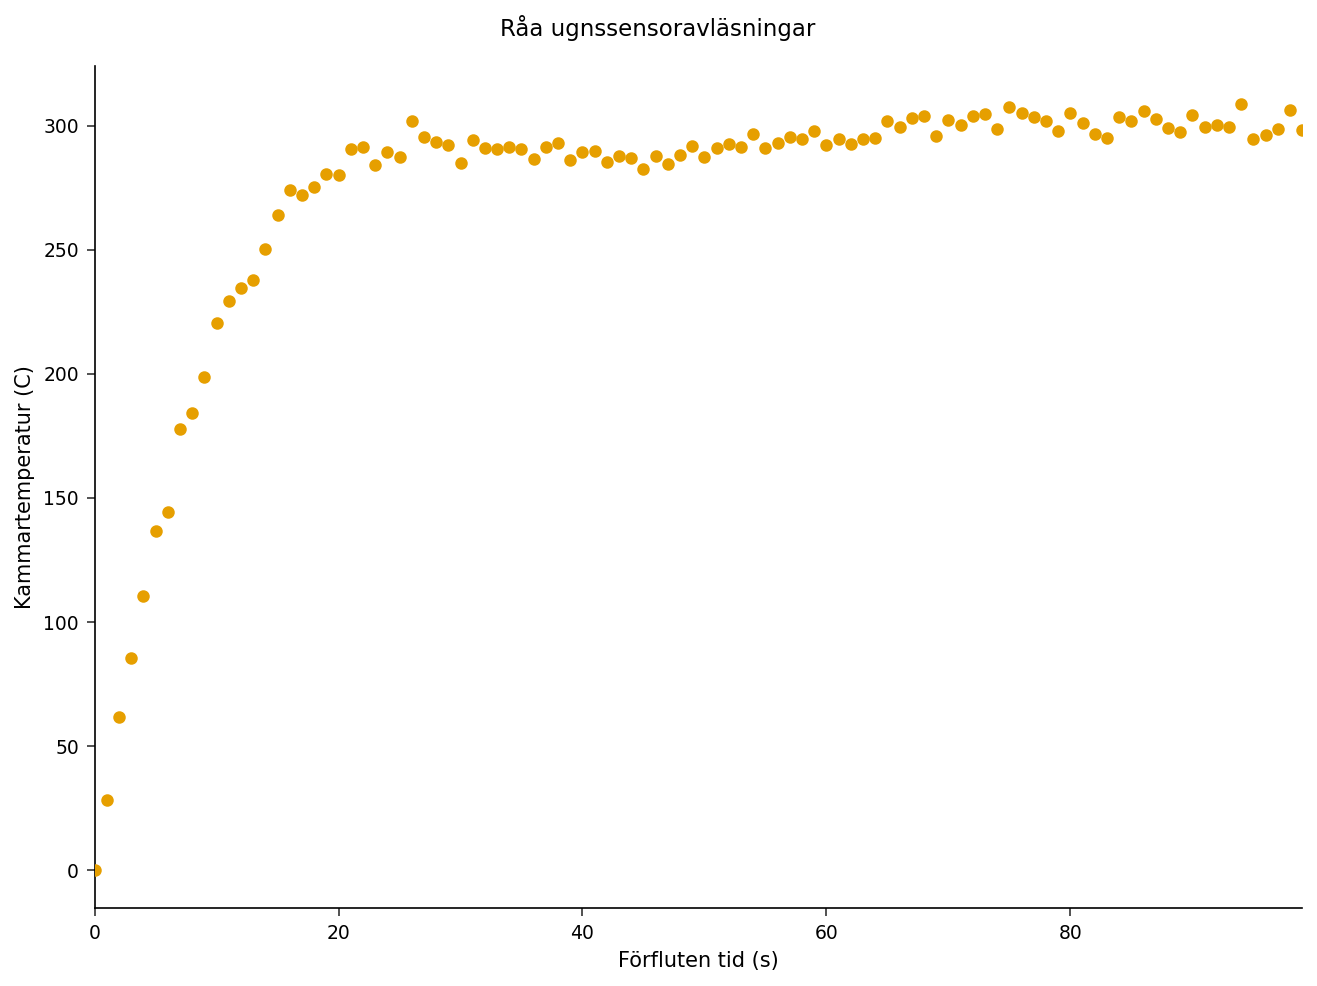

In [2]:
ODS GRAPHICS ON;

PROCEDUR SGPLOT data=sensor;
    SCATTER x=t y=temp / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETIKETT='Förfluten tid (s)';
    YAXIS ETIKETT='Kammartemperatur (C)';
    TITEL 'Råa ugnssensoravläsningar';
KÖR;

ODS GRAPHICS OFF;

## Steg 3 — Anpassa LOESS med automatiskt vald bandbredd

Utjämningsparametern styr hur brett varje lokalt grannskap är: för litet överanpassar bruset, för stort suddar ut översläng. Istället för att gissa låter vi LOESS välja den genom att minimera det **korrigerade Akaike-informationskriteriet** med `select=AICC`. Vi använder lokala kvadratiska polynom (`degree=2`) så att kurvan kan följa krökningen i uppvärmningen och översläng, och begär ett 95-procentigt konfidensband med `clm` och `alpha=0.05`.

`ODS OUTPUT` fångar två tabeller som dataset: `OutputStatistics` (utjämnade värden och residualer per punkt) och `FitSummary` (den valda bandbredden och anpassningsdiagnostik). `OUTPUT`-satsen skriver ett `fitted`-dataset med prediktionen, residualen och 95-procentiga konfidensgränser för varje observation — råmaterialet för de diagram som följer.

In [3]:
PROCEDUR loess data=sensor;
    ODS OUTPUT OutputStatistics=loess_fit
               FitSummary=fit_summary;
    MODEL temp = t / DEGREE=2 select=AICC CLM ALPHA=0.05 details;
    UTDATA out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
KÖR;

                                            De första 8 sensoravläsningarna                                             


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Steg 4 — Granska den valda modellen

Fit Summary-tabellen redovisar den AICC-optimala utjämningsparametern och spåret av prediktionsmatrisen (de effektiva frihetsgraderna — ett mått på modellens komplexitet). En mindre utjämningsparameter och ett större DF innebär en mer krokig anpassning; AICC balanserar anpassning mot komplexitet automatiskt.

In [4]:
PROCEDUR SKRIV data=fit_summary noobs ETIKETT;
    TITEL 'LOESS-anpassningssammanfattning (AICC-vald bandbredd)';
KÖR;

                                 LOESS-anpassningssammanfattning (AICC-vald bandbredd)                                  

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Steg 5 — Lägg den anpassade kurvan och konfidensbandet över sanningen

Eftersom detta är simulerad data behöll vi den brusfria kolumnen `truth`. Att plotta LOESS-skattningen och dess 95-procentiga band tillsammans med `truth` visar hur troget utjämnaren återskapade den bakomliggande signalen den aldrig såg direkt.

                                 LOESS-anpassningssammanfattning (AICC-vald bandbredd)                                  




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


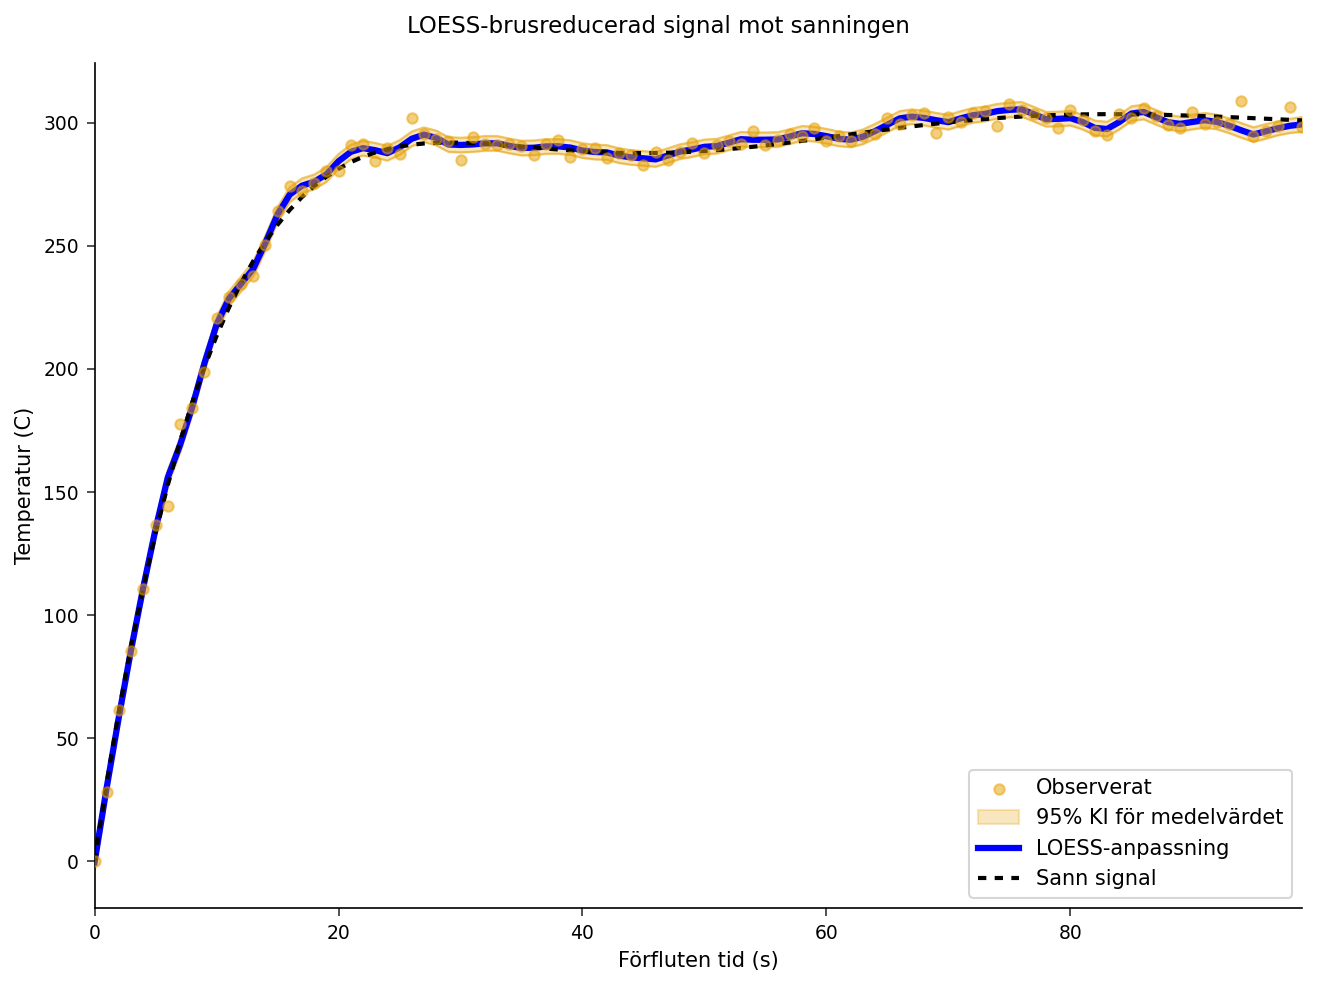

In [5]:
PROCEDUR SORTERA data=fitted; EFTER t; KÖR;

ODS GRAPHICS ON;

PROCEDUR SGPLOT data=fitted;
    SCATTER x=t y=temp / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='Observerat';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='95% KI för medelvärdet';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS-anpassning';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='Sann signal';
    XAXIS ETIKETT='Förfluten tid (s)';
    YAXIS ETIKETT='Temperatur (C)';
    TITEL 'LOESS-brusreducerad signal mot sanningen';
KÖR;

ODS GRAPHICS OFF;

## Steg 6 — Residualdiagnostik

Residualerna (observerat minus anpassat) bör se ut som strukturlöst brus centrerat kring noll. Varje kvarvarande trend skulle signalera underutjämning eller ett förbisett inslag. Vi plottar residualerna mot tiden och sammanfattar deras spridning — residualernas standardavvikelse blir 3,10 °C, en aning under de 4 °C brus vi injicerade eftersom den lokala anpassningen absorberar en liten andel av det.

                                 LOESS-anpassningssammanfattning (AICC-vald bandbredd)                                  

                                      Residualsammanfattning (återvunnet mätbrus)                                       

                                                  The MEANS Procedure

 Variable  Label            N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------
 RESID     Residual       100       0.139       3.096     -11.688      11.909
 ----------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


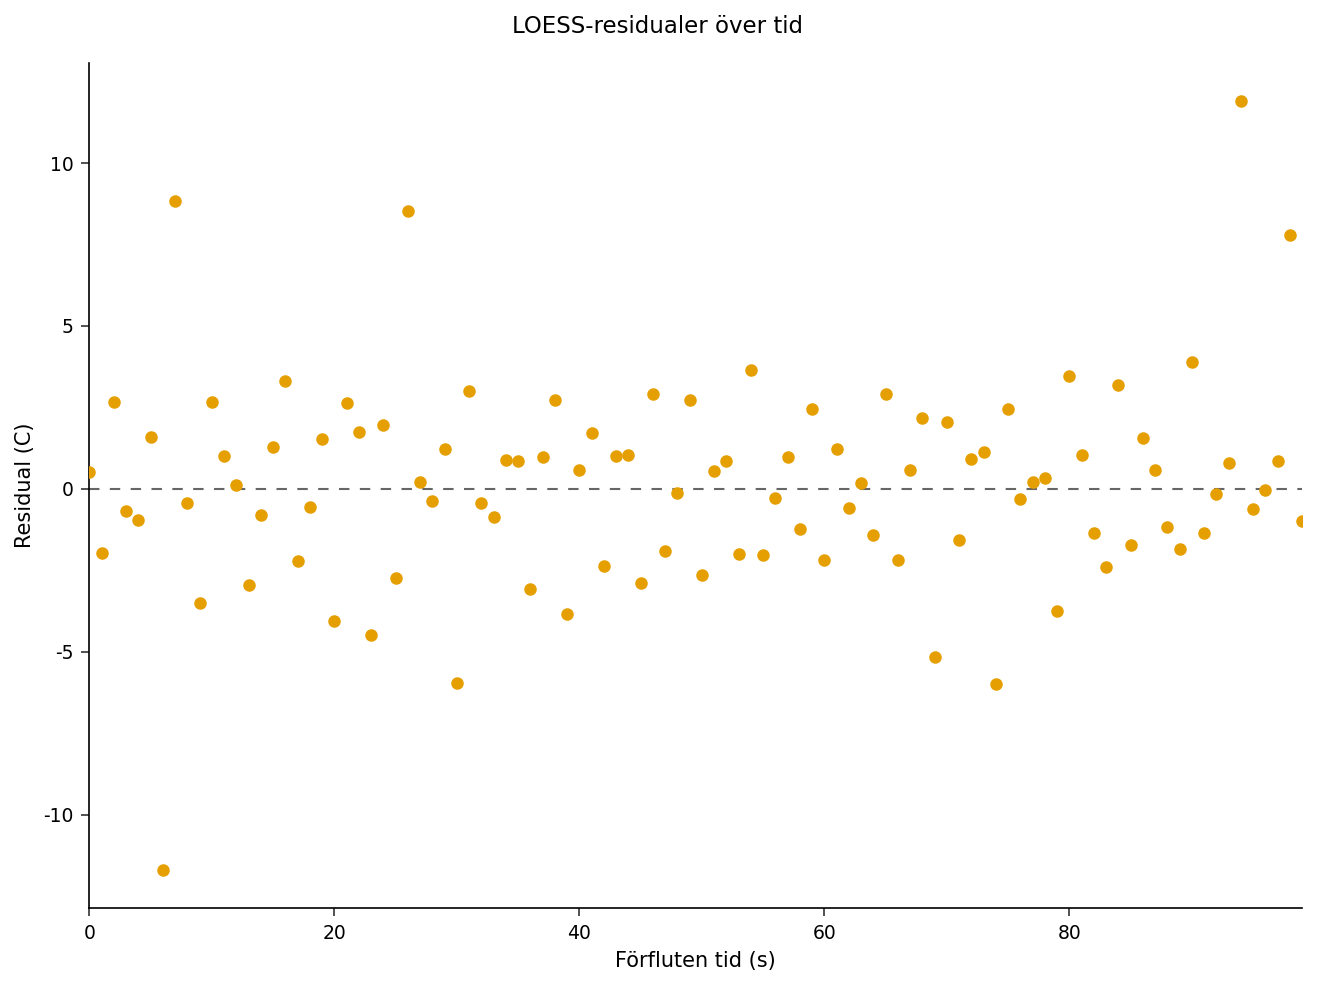

In [6]:
ODS GRAPHICS ON;

PROCEDUR SGPLOT data=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS ETIKETT='Förfluten tid (s)';
    YAXIS ETIKETT='Residual (C)';
    TITEL 'LOESS-residualer över tid';
KÖR;

ODS GRAPHICS OFF;

PROCEDUR MEDELVÄRDEN data=fitted n mean std MIN MAX maxdec=3;
    VARIABEL resid;
    TITEL 'Residualsammanfattning (återvunnet mätbrus)';
KÖR;

## Steg 7 — Bedöm ett regelbundet övervakningsraster för SPC

Sensorns tidsstämplar behöver inte vara jämnt fördelade, men ett styrdiagram vill ha signalen i en fast takt. Vi bygger ett enhetligt tidsraster med 60 punkter och tillämpar den anpassade LOESS-modellen på det med `SCORE`-satsen, och begär konfidensgränser. De bedömda värdena är en ren, jämnt fördelad signal redo att mata en SPC-rutin.

In [7]:
data grid;
    GÖR t = 0 TILL 99 EFTER 99/59;
        UTDATA;
    SLUT;
KÖR;

PROCEDUR loess data=sensor;
    MODEL temp = t / DEGREE=2 select=AICC CLM ALPHA=0.05;
    SCORE data=grid CLM SKRIV;
    TITEL 'LOESS bedömd på ett enhetligt övervakningsraster';
KÖR;

                                      Residualsammanfattning (återvunnet mätbrus)                                       


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Steg 8 — Kvantifiera brusreduceringen

Slutligen jämför vi rådatasignalen och LOESS-skattningen mot den kända sanningen. Medelkvadratfelet för den utjämnade signalen bör vara betydligt mindre än för rådata, vilket bekräftar att LOESS tog bort mätbruset samtidigt som uppvärmningsrampen och översläng bevarades.

In [8]:
data accuracy;
    STÄLL_IN fitted;
    raw_sq_err   = (temp     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
KÖR;

PROCEDUR MEDELVÄRDEN data=accuracy mean maxdec=3;
    VARIABEL raw_sq_err loess_sq_err;
    ETIKETT raw_sq_err   = 'MSE för råa avläsningar mot sanningen'
          loess_sq_err = 'MSE för LOESS-anpassning mot sanningen';
    TITEL 'Brusreduceringsprestanda: råa vs. LOESS';
KÖR;

                                        Brusreduceringsprestanda: råa vs. LOESS                                         

                                                  The MEANS Procedure

 Variable      Label                                              Mean
 ---------------------------------------------------------------------
 raw_sq_err    MSE för råa avläsningar mot sanningen            14.774
 loess_sq_err  MSE för LOESS-anpassning mot sanningen            6.629
 ---------------------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Tolkning av resultaten

- **Automatisk bandbredd.** `select=AICC` valde en utjämningsparameter på **0,08** utan manuell justering, vilket motsvarar cirka **8 ekvivalenta parametrar** — tillräcklig lokal flexibilitet för att följa uppvärmningen, översläng och dippen, samtidigt som bruset jämnas ut.
- **Trogen återskapning.** Den anpassade kurvan följer den bakomliggande `truth`-signalen nära genom rampen, översläng-toppen nära t = 28 och den avklingande svansen, vilket visar att LOESS återskapade en godtycklig olinjär signal utan parametriska antaganden.
- **Rena residualer.** Residualerna sprider sig kring noll med en standardavvikelse på **3,10 °C** (medelvärde 0,14, intervall −11,7 till 11,9) och visar ingen kvarvarande tidstrend — belägg för att modellen varken är över- eller underutjämnad.
- **Mätbar brusreducering.** Jämfört med sanningen sänker LOESS-skattningen medelkvadratfelet från **14,77** (rådata) till **6,63** — en minskning med 55 %, huvudvinsten för processövervakning.
- **SPC-klart resultat.** SCORE-steget levererade den brusreducerade signalen på ett enhetligt raster med 60 punkter och konfidensgränser, exakt den form ett nedströms styrdiagram tar emot.

**Slutsats:** När en processensor producerar en jämn men brusig signal av okänd form är PROC LOESS ett antagandesnålt, självjusterande sätt att extrahera den underliggande trenden, lägga till osäkerhetsgränser och omsampla till ett övervakningsraster — allt utan att binda sig till en parametrisk modell som fysiken kanske inte motiverar.